# Sentiment Analysis
## Oasis Infobyte — Data Analytics Internship
### Name: Priti Ranjit | Track: Data Analytics | Task: L1 Task 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df_raw = pd.read_csv('train.csv', encoding='latin1')

print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()

Shape: (27481, 10)

Columns: ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


## Step 1: Data Cleaning & Class Distribution

In [3]:
print("Available columns:", list(df_raw.columns))

# Select only text and sentiment columns using their exact names
df = df_raw.loc[:, ['text', 'sentiment']].copy()

# Drop missing values
df = df.dropna()

print("\nShape after cleaning:", df.shape)
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

Available columns: ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

Shape after cleaning: (27480, 2)

Class Distribution:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


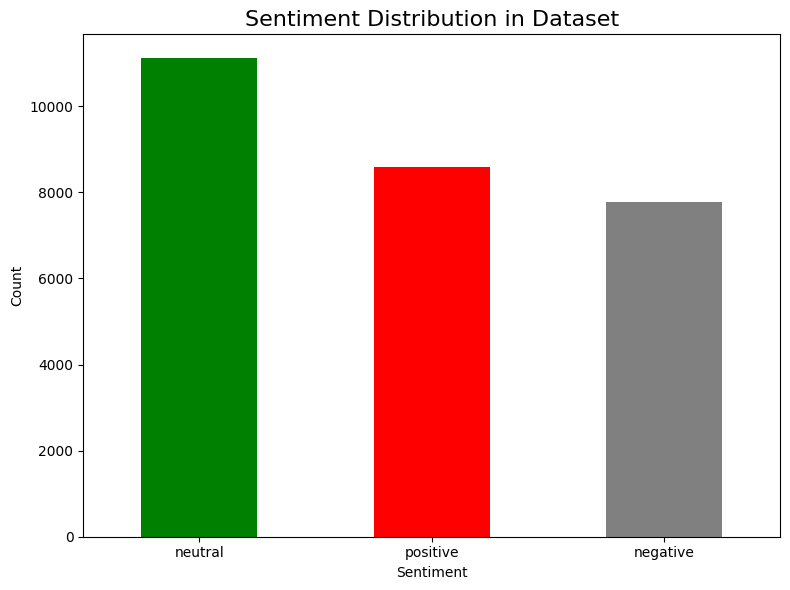

In [4]:
plt.figure(figsize=(8, 6))
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution in Dataset', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

## Step 2: Text Preprocessing Pipeline

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

print("Cleaning complete!")
print("\nExample:")
print("Original:", df['text'].iloc[0])
print("Cleaned :", df['cleaned_text'].iloc[0])

Cleaning complete!

Example:
Original:  I`d have responded, if I were going
Cleaned : id have responded if i were going


## Step 3: TF-IDF Feature Extraction
TF-IDF measures how important a word is to a document relative 
to the entire dataset, giving higher weight to distinctive words.

In [6]:
df = df[df['cleaned_text'].str.strip() != '']

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['cleaned_text'])
y = df['sentiment']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (27474, 5000)


## Step 4: Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 21979
Test size: 5495


## Step 5: Train Models

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_predictions = nb_model.predict(X_test)
print("Naive Bayes trained!")

Naive Bayes trained!


In [9]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print("Logistic Regression trained!")

Logistic Regression trained!


## Step 6: Model Evaluation

In [10]:
print("NAIVE BAYES")
print("Accuracy:", accuracy_score(y_test, nb_predictions))
print(classification_report(y_test, nb_predictions))

print("\nLOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, lr_predictions))
print(classification_report(y_test, lr_predictions))

NAIVE BAYES
Accuracy: 0.6394904458598726
              precision    recall  f1-score   support

    negative       0.75      0.49      0.59      1556
     neutral       0.56      0.78      0.65      2223
    positive       0.74      0.60      0.66      1716

    accuracy                           0.64      5495
   macro avg       0.68      0.62      0.63      5495
weighted avg       0.67      0.64      0.64      5495


LOGISTIC REGRESSION
Accuracy: 0.6804367606915378
              precision    recall  f1-score   support

    negative       0.73      0.56      0.64      1556
     neutral       0.61      0.77      0.68      2223
    positive       0.78      0.67      0.72      1716

    accuracy                           0.68      5495
   macro avg       0.71      0.67      0.68      5495
weighted avg       0.70      0.68      0.68      5495



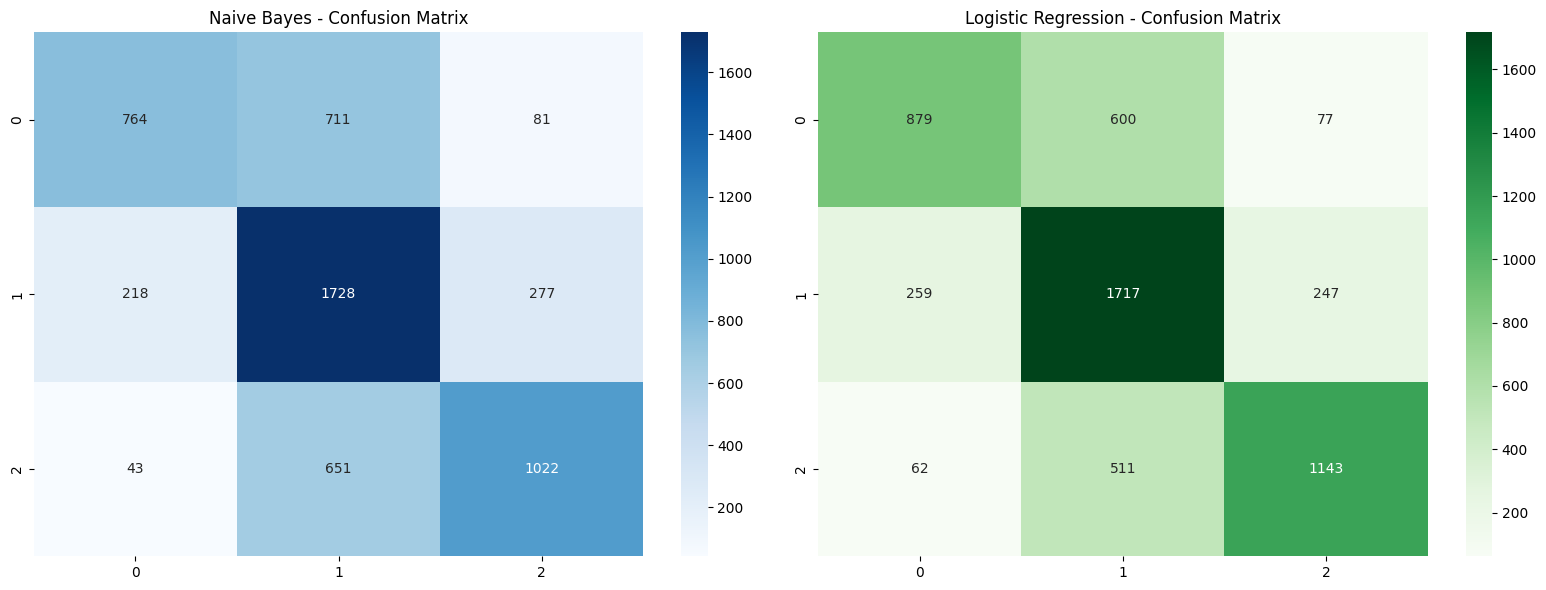

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_nb = confusion_matrix(y_test, nb_predictions)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes - Confusion Matrix')

cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression - Confusion Matrix')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

## Step 7: WordCloud Visualization

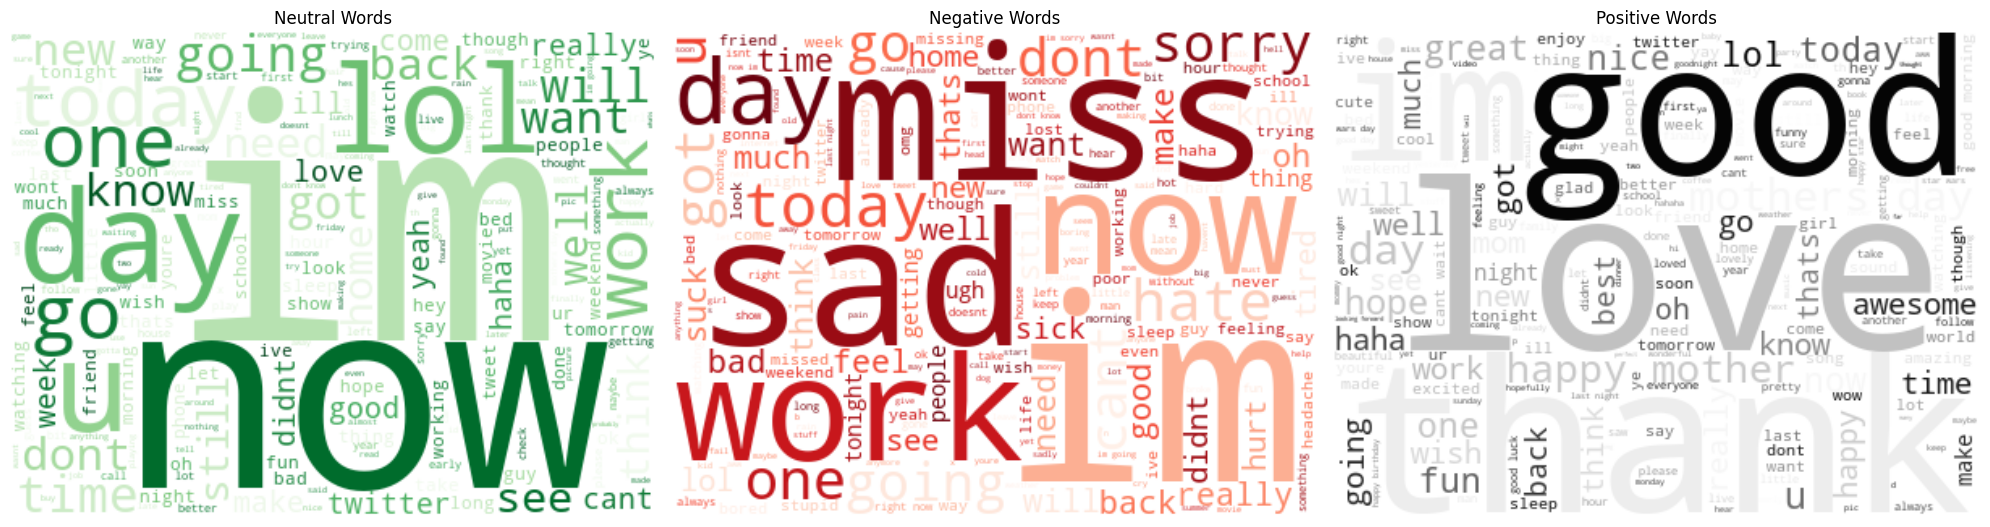

In [12]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sentiments = df['sentiment'].unique()
colors = ['Greens', 'Reds', 'Greys']

for i, sentiment in enumerate(sentiments[:3]):
    text_data = ' '.join(df[df['sentiment'] == sentiment]['cleaned_text'])
    if len(text_data.strip()) > 0:
        wordcloud = WordCloud(width=400, height=300, 
                               background_color='white',
                               colormap=colors[i]).generate(text_data)
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f'{sentiment.capitalize()} Words')
        axes[i].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png')
plt.show()

## Conclusion

### Key Findings:
Both Naive Bayes and Logistic Regression were trained on 
TF-IDF features to classify tweet sentiment as positive, 
negative, or neutral.

### Why Recall Matters:
High recall for negative sentiment is critical in real-world 
applications — missing negative feedback could mean failing 
to address customer complaints in time.

### Real-World Application:
This model could power social media brand monitoring, 
flagging negative reviews for priority customer support.